# WriteLens - Feature Engineering

Ekstrak fitur stylometric, cek mana yang diskriminatif buat human vs AI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import json
import warnings
from collections import Counter
from scipy import stats
from tqdm import tqdm
sns.set_style('darkgrid')

tqdm.pandas()
warnings.filterwarnings('ignore')

Load hasil cleaning dari EDA: daigt_v2_clean.csv dan mage_clean.csv.

In [2]:
daigt = pd.read_csv("daigt_v2_clean.csv")
mage  = pd.read_csv("mage_clean.csv")
print(daigt.shape, mage.shape)

(44866, 5) (371981, 4)


## Fitur Stylometric

~20 fitur, 6 kategori: sentence-level, lexical diversity, word choice, punctuation, readability, pattern. Hipotesis: AI lebih konsisten, lebih banyak transition words, kata lebih kompleks.

Word sets didefinisikan manual: STOPWORDS, CONJUNCTIONS, TRANSITION_WORDS, PRONOUNS. Dipakai di dalam extract_features.

In [3]:
# word sets
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "of", "to", "in", "on", "at",
    "for", "with", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "do", "does", "did", "i", "you", "he", "she",
    "it", "we", "they", "this", "that", "these", "those", "by", "as",
    "not", "from", "so", "if", "its", "my", "your", "our", "their",
    "which", "what", "when", "where", "who", "whom", "how",
    "all", "each", "every", "both", "few", "more", "most", "other",
    "some", "such", "no", "nor", "only", "own", "same", "than",
    "too", "very", "can", "will", "just", "should", "now",
}

CONJUNCTIONS = {
    "and", "but", "or", "nor", "for", "yet", "so",
    "however", "moreover", "furthermore", "additionally",
    "nevertheless", "meanwhile", "therefore", "consequently",
    "although", "whereas", "while",
}

TRANSITION_WORDS = {
    "however", "therefore", "moreover", "furthermore", "additionally",
    "consequently", "nevertheless", "meanwhile", "similarly",
    "subsequently", "accordingly", "conversely", "alternatively",
    "specifically", "particularly", "notably", "indeed",
}

PRONOUNS = {
    "i", "me", "my", "mine", "myself",
    "you", "your", "yours", "yourself",
    "he", "him", "his", "himself",
    "she", "her", "hers", "herself",
    "it", "its", "itself",
    "we", "us", "our", "ours", "ourselves",
    "they", "them", "their", "theirs", "themselves",
}

VOWEL_RE   = re.compile(r'[aeiouy]+')
WORD_RE    = re.compile(r"[A-Za-z']+")
SENT_RE    = re.compile(r'[.!?]+(?:\s|$)')
PUNCT_RE   = re.compile(r'[.,;:!?\-"\'()\[\]]')
PASSIVE_RE = re.compile(r'\b(?:was|were|been|be|is|are)\s+\w+ed\b')

In [4]:
def count_syllables(word):
    word = word.lower()
    groups = VOWEL_RE.findall(word)
    n = len(groups)
    if n == 0:
        return 1
    if word.endswith('e') and n > 1:
        n -= 1
    return n

def extract_features(text):
    try:
        text = str(text)
        if len(text) < 20:
            return None

        sents_raw = SENT_RE.split(text)
        sents = [s.strip() for s in sents_raw if s.strip()]
        if len(sents) < 1:
            return None

        words = WORD_RE.findall(text)
        words_lower = [w.lower() for w in words]
        n_words = len(words)
        if n_words < 5:
            return None

        sent_word_counts = [len(WORD_RE.findall(s)) for s in sents]
        sent_word_counts = [c for c in sent_word_counts if c > 0]
        if not sent_word_counts:
            return None

        avg_sentence_length = float(np.mean(sent_word_counts))
        sentence_length_std = float(np.std(sent_word_counts))
        short_sentence_ratio = sum(1 for c in sent_word_counts if c < 8) / len(sent_word_counts)
        long_sentence_ratio  = sum(1 for c in sent_word_counts if c > 25) / len(sent_word_counts)

        wc = Counter(words_lower)
        ttr = len(wc) / n_words
        hapax_ratio = sum(1 for w, c in wc.items() if c == 1) / n_words
        avg_word_length = float(np.mean([len(w) for w in words]))

        function_word_ratio = sum(1 for w in words_lower if w in STOPWORDS) / n_words
        conjunction_rate    = sum(1 for w in words_lower if w in CONJUNCTIONS) / n_words
        pronoun_used = {w for w in words_lower if w in PRONOUNS}
        pronoun_diversity = len(pronoun_used) / len(PRONOUNS)

        n_punct = len(PUNCT_RE.findall(text))
        punctuation_density = n_punct / n_words
        n_comma = text.count(',')
        comma_ratio = (n_comma / n_punct) if n_punct > 0 else 0.0
        question_mark_ratio = text.count('?') / len(sents)
        exclamation_ratio   = text.count('!') / len(sents)

        syl = [count_syllables(w) for w in words_lower]
        syllable_per_word = float(np.mean(syl)) if syl else 0.0
        flesch_reading_ease = 206.835 - (1.015 * avg_sentence_length) - (84.6 * syllable_per_word)
        paragraph_count = len([p for p in text.split('\n\n') if p.strip()])

        bigrams = list(zip(words_lower[:-1], words_lower[1:]))
        if bigrams:
            bc = Counter(bigrams)
            bigram_repetition_rate = sum(1 for _, c in bc.items() if c > 1) / len(bigrams)
        else:
            bigram_repetition_rate = 0.0

        transition_word_density = sum(1 for w in words_lower if w in TRANSITION_WORDS) / n_words
        passive_hits = len(PASSIVE_RE.findall(text.lower()))
        passive_voice_estimate = passive_hits / len(sents)

        return {
            "avg_sentence_length": avg_sentence_length,
            "sentence_length_std": sentence_length_std,
            "short_sentence_ratio": short_sentence_ratio,
            "long_sentence_ratio": long_sentence_ratio,
            "ttr": ttr,
            "hapax_ratio": hapax_ratio,
            "avg_word_length": avg_word_length,
            "function_word_ratio": function_word_ratio,
            "conjunction_rate": conjunction_rate,
            "pronoun_diversity": pronoun_diversity,
            "punctuation_density": punctuation_density,
            "comma_ratio": comma_ratio,
            "question_mark_ratio": question_mark_ratio,
            "exclamation_ratio": exclamation_ratio,
            "syllable_per_word": syllable_per_word,
            "flesch_reading_ease": flesch_reading_ease,
            "paragraph_count": paragraph_count,
            "bigram_repetition_rate": bigram_repetition_rate,
            "transition_word_density": transition_word_density,
            "passive_voice_estimate": passive_voice_estimate,
        }
    except Exception:
        return None

Test ekstraksi pada satu sampel teks dari DAIGT.

In [5]:
# test dulu
ex = extract_features(daigt['text'].iloc[0])
for k, v in ex.items():
    print(f"  {k}: {v:.4f}")

  avg_sentence_length: 14.0000
  sentence_length_std: 7.3384
  short_sentence_ratio: 0.2222
  long_sentence_ratio: 0.1111
  ttr: 0.4894
  hapax_ratio: 0.3122
  avg_word_length: 4.2566
  function_word_ratio: 0.4471
  conjunction_rate: 0.0476
  pronoun_diversity: 0.2000
  punctuation_density: 0.1217
  comma_ratio: 0.0652
  question_mark_ratio: 0.0000
  exclamation_ratio: 0.0000
  syllable_per_word: 1.3201
  flesch_reading_ease: 80.9440
  paragraph_count: 6.0000
  bigram_repetition_rate: 0.0769
  transition_word_density: 0.0000
  passive_voice_estimate: 0.0370


## Extract Features

In [6]:
# DAIGT
feat_list = daigt['text'].progress_apply(extract_features)
feat_daigt = pd.DataFrame([f for f in feat_list if f is not None])
keep_mask = feat_list.apply(lambda x: x is not None)
feat_daigt['label']   = daigt.loc[keep_mask, 'label'].values
feat_daigt['dataset'] = 'daigt_v2'
print(f"DAIGT: {feat_daigt.shape}, drop {(~keep_mask).sum()}")

100%|██████████| 44866/44866 [00:45<00:00, 990.03it/s] 


DAIGT: (44866, 22), drop 0


MAGE di-sample 15.000 per label -- tidak semua diproses karena ukurannya 370k+ baris.

In [7]:
# MAGE - sample 15k per class biar nggak lama
mage_h = mage[mage['label']==0].sample(min(15000, (mage['label']==0).sum()), random_state=42)
mage_a = mage[mage['label']==1].sample(min(15000, (mage['label']==1).sum()), random_state=42)
mage_samp = pd.concat([mage_h, mage_a], ignore_index=True)

feat_list_m = mage_samp['text'].progress_apply(extract_features)
feat_mage = pd.DataFrame([f for f in feat_list_m if f is not None])
keep_m = feat_list_m.apply(lambda x: x is not None)
feat_mage['label']   = mage_samp.loc[keep_m, 'label'].values
feat_mage['dataset'] = 'mage'
print(f"MAGE: {feat_mage.shape}, drop {(~keep_m).sum()}")

100%|██████████| 30000/30000 [00:13<00:00, 2153.01it/s]


MAGE: (30000, 22), drop 0


In [8]:
feat_df = pd.concat([feat_daigt, feat_mage], ignore_index=True)
feature_cols = [c for c in feat_df.columns if c not in ('label', 'dataset')]
print(f"Total: {len(feat_df)} rows, {len(feature_cols)} fitur")
feat_df['label'].value_counts()

Total: 74866 rows, 20 fitur


label
0    42371
1    32495
Name: count, dtype: int64

In [9]:
feat_df.to_csv("all_features.csv", index=False)

## Distribusi Fitur

Box plot distribusi tiap fitur: human vs AI. Di-clip di persentil 1-99 biar outlier tidak distorsi visual.

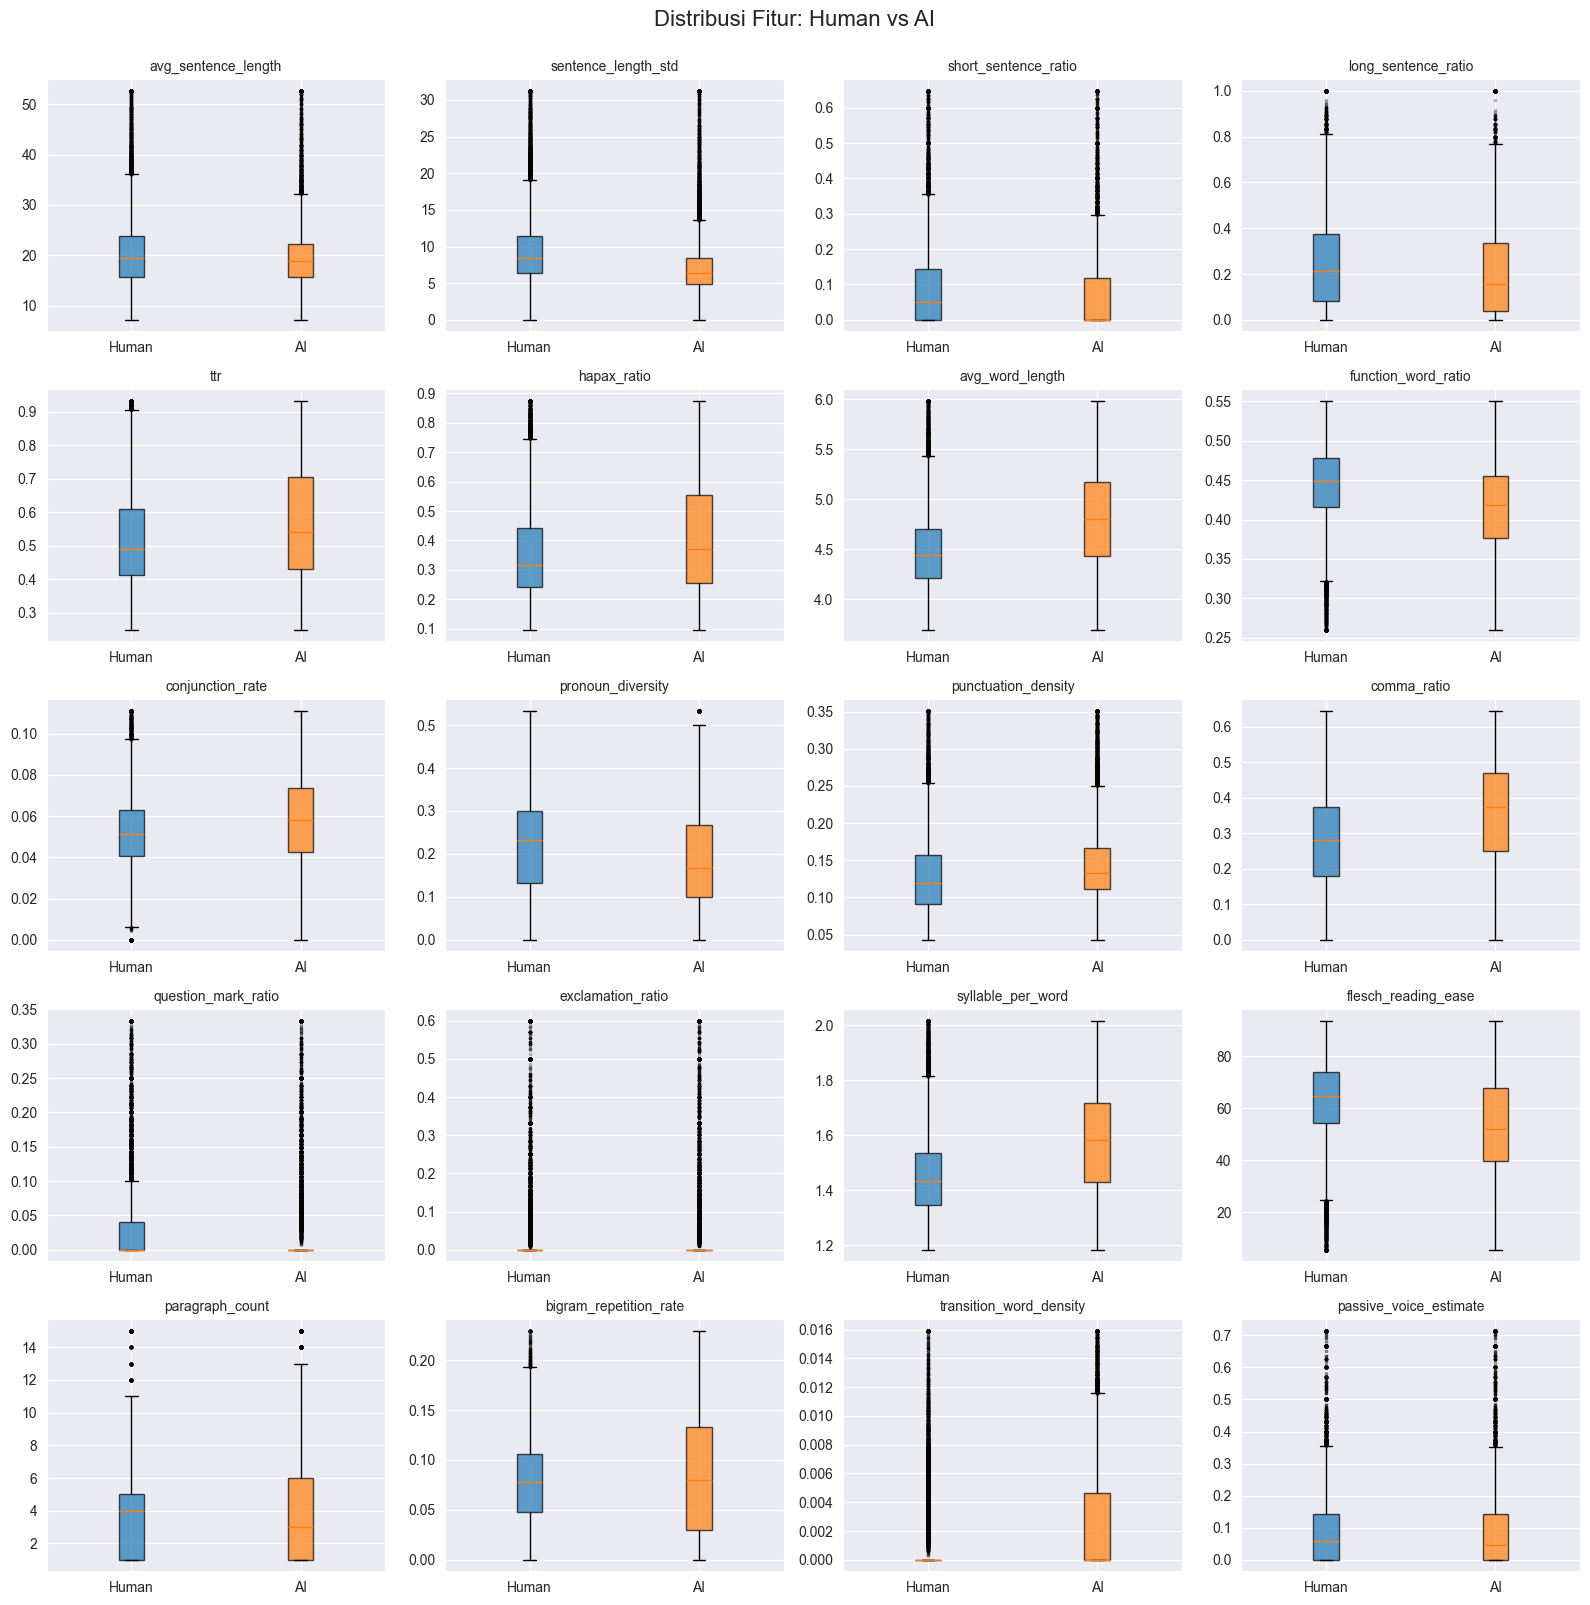

In [10]:
n_feat = len(feature_cols)
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2*nrows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    h = feat_df.loc[feat_df['label']==0, col].dropna()
    a = feat_df.loc[feat_df['label']==1, col].dropna()
    q_lo, q_hi = np.percentile(pd.concat([h, a]), [1, 99])
    bp = ax.boxplot([h.clip(q_lo, q_hi), a.clip(q_lo, q_hi)], labels=['Human','AI'], patch_artist=True,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    for patch, c in zip(bp['boxes'], ['tab:blue', 'tab:orange']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Distribusi Fitur: Human vs AI", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## Uji Statistik + Ranking

Mann-Whitney U untuk uji signifikansi. Cohen's d untuk ukuran efek -- semakin besar, semakin diskriminatif fiturnya.

In [11]:
# cohen's d + mann-whitney per fitur
res = []
for col in feature_cols:
    h = feat_df.loc[feat_df['label']==0, col].dropna()
    a = feat_df.loc[feat_df['label']==1, col].dropna()
    pooled = np.sqrt((h.std()**2 + a.std()**2) / 2)
    d = abs((a.mean() - h.mean()) / pooled) if pooled > 0 else 0.0
    _, pval = stats.mannwhitneyu(h, a, alternative='two-sided')
    res.append({"feature": col, "mean_human": h.mean(), "mean_ai": a.mean(),
                "cohens_d": d, "pval": pval})

res_df = pd.DataFrame(res).sort_values("cohens_d", ascending=False).reset_index(drop=True)
res_df

,feature,mean_human,mean_ai,cohens_d,pval
0,syllable_per_word,1.455061,1.580977,0.701247,0.000000e+00
1,avg_word_length,4.481787,4.813640,0.697691,0.000000e+00
2,function_word_ratio,0.443399,0.413072,0.513082,0.000000e+00
3,transition_word_density,0.001007,0.002824,0.499699,0.000000e+00
4,comma_ratio,0.278395,0.352550,0.484230,0.000000e+00
5,flesch_reading_ease,62.394337,52.792254,0.445208,0.000000e+00
6,pronoun_diversity,0.223521,0.185518,0.329259,0.000000e+00
7,hapax_ratio,0.358053,0.414685,0.308567,2.337748e-279
8,ttr,0.520719,0.570345,0.301279,0.000000e+00
9,punctuation_density,0.129978,0.148452,0.277638,0.000000e+00


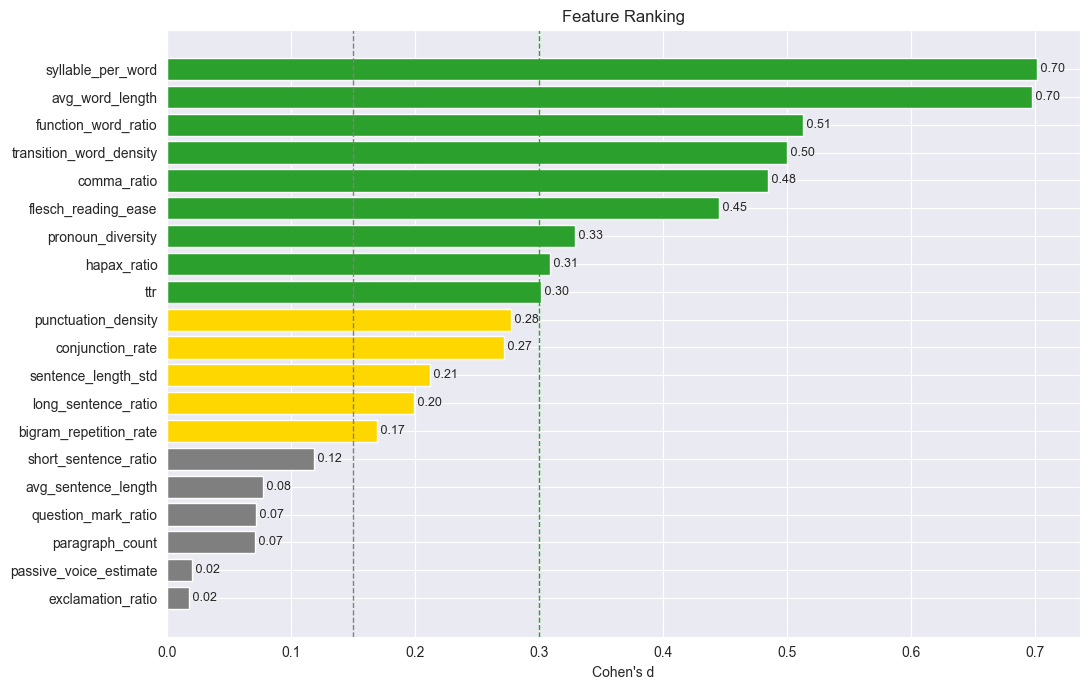

In [12]:
order = res_df.sort_values("cohens_d", ascending=True)
colors = ['tab:green' if d > 0.3 else 'gold' if d >= 0.15 else 'tab:gray' for d in order["cohens_d"]]

fig, ax = plt.subplots(figsize=(11, max(6, len(order)*0.35)))
ax.barh(order["feature"], order["cohens_d"], color=colors)
ax.axvline(0.15, color='gray', ls='--', lw=1)
ax.axvline(0.30, color='tab:green', ls='--', lw=1)
ax.set_xlabel("Cohen's d")
ax.set_title("Feature Ranking")
for i, v in enumerate(order["cohens_d"]):
    ax.text(v, i, f" {v:.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Correlation + Seleksi

Heatmap korelasi antar 20 fitur. Pasangan dengan korelasi > 0.85 dianggap redundan.

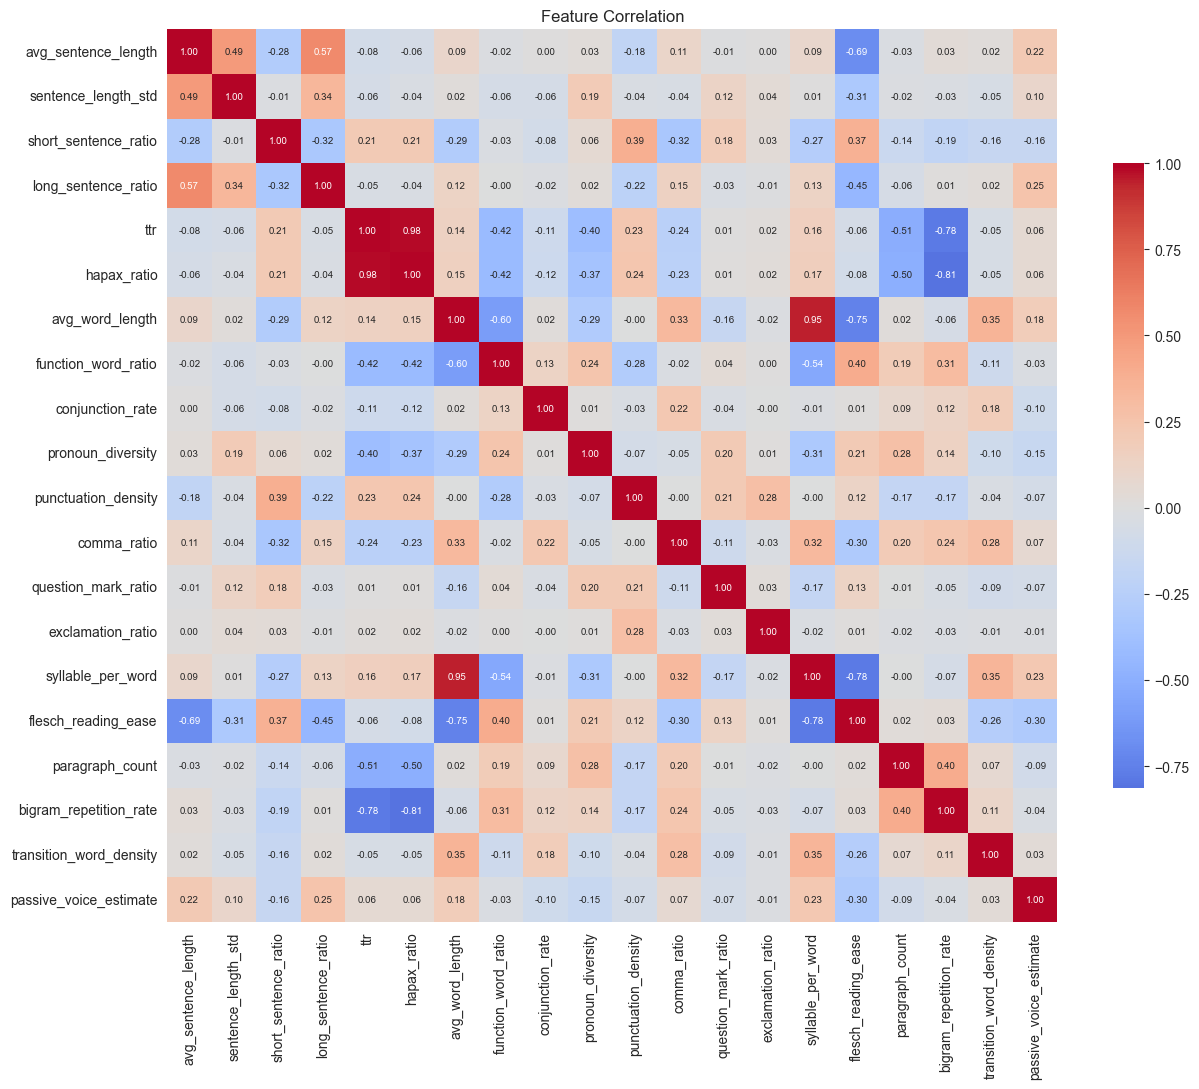

  ttr <-> hapax_ratio: 0.984
  avg_word_length <-> syllable_per_word: 0.947


In [13]:
corr = feat_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'shrink': 0.7}, annot_kws={"size": 7})
ax.set_title("Feature Correlation")
plt.tight_layout()
plt.show()

# cek pasangan korelasi > 0.85
corr_abs = corr.abs()
pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        v = corr_abs.iloc[i, j]
        if v > 0.85:
            pairs.append((feature_cols[i], feature_cols[j], float(v)))
            print(f"  {feature_cols[i]} <-> {feature_cols[j]}: {v:.3f}")
if not pairs:
    print("  (nggak ada)")

Kriteria seleksi: Cohen's d >= 0.15. Kalau dua fitur redundan (korelasi > 0.85), yang Cohen's d-nya lebih kecil di-drop.

In [14]:
# seleksi: cohen's d >= 0.15, drop redundant (korelasi > 0.85, keep yang d-nya lebih gede)
d_map = dict(zip(res_df['feature'], res_df['cohens_d']))
selected = [f for f in feature_cols if d_map[f] >= 0.15]

for a, b, v in pairs:
    if a in selected and b in selected:
        drop = b if d_map[a] >= d_map[b] else a
        selected.remove(drop)
        print(f"drop {drop} (d={d_map[drop]:.3f}, redundant with {a if drop==b else b})")

selected = sorted(selected, key=lambda x: -d_map[x])
print(f"\nFitur terpilih ({len(selected)}):")
for f in selected:
    print(f"  {f}  d={d_map[f]:.3f}")

drop ttr (d=0.301, redundant with hapax_ratio)
drop avg_word_length (d=0.698, redundant with syllable_per_word)

Fitur terpilih (12):
  syllable_per_word  d=0.701
  function_word_ratio  d=0.513
  transition_word_density  d=0.500
  comma_ratio  d=0.484
  flesch_reading_ease  d=0.445
  pronoun_diversity  d=0.329
  hapax_ratio  d=0.309
  punctuation_density  d=0.278
  conjunction_rate  d=0.272
  sentence_length_std  d=0.212
  long_sentence_ratio  d=0.199
  bigram_repetition_rate  d=0.169


## Range + Simpan

Range persentil 15-85 per label disimpan ke feature_ranges.json -- dipakai backend app untuk interpretasi output model.

In [15]:
# range per fitur buat backend app
ranges = {}
for f in selected:
    h = feat_df.loc[feat_df['label']==0, f].dropna()
    a = feat_df.loc[feat_df['label']==1, f].dropna()
    all_v = feat_df[f].dropna()
    ranges[f] = {
        "human_low":  float(np.percentile(h, 15)),
        "human_high": float(np.percentile(h, 85)),
        "ai_low":     float(np.percentile(a, 15)),
        "ai_high":    float(np.percentile(a, 85)),
        "scale_min":  float(np.percentile(all_v, 2)),
        "scale_max":  float(np.percentile(all_v, 98)),
    }

with open("feature_ranges.json", "w") as fp:
    json.dump(ranges, fp, indent=2)
print("saved feature_ranges.json")

saved feature_ranges.json


In [16]:
features_final = feat_df[selected + ['label', 'dataset']].copy()
features_final.to_csv("features_final.csv", index=False)
print(f"Saved features_final.csv: {features_final.shape}")
features_final['label'].value_counts()

Saved features_final.csv: (74866, 14)


label
0    42371
1    32495
Name: count, dtype: int64